# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

# **Chapter 22:TinyStories**

### **Section 1: npyファイルへの変換**

質問です！

検証誤差を下げる方法にはどうすればいいでしょうか？

もちろんいろんな回答があると思います。

1つとてもシンプルな解決策は、そもそも学習するデータセットを簡単にするということです。

そこで登場するのが昔話のデータセットである [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories)　です。

これはGPT3.5によって合成された昔話の大規模データセットです。

finewebデータセットのようなweb上のブログやwikipediaのような百科事典の続きを予測するよりも、昔話の続きを予測する方が簡単だと思いませんか？実際にそうです。

finewebデータセット相手だとColabのT4 GPUではあまり勝負にならないのですが、この TinyStoriesデータセットなら十分な性能が得られます。

ここからは TinyStoriesが標準のデータセットとなります、それではレッツゴー！

In [ ]:
!wget https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStories-train.txt

In [ ]:
!head /content/TinyStories-train.txt

1つ目の昔話を読んでみましょう。読みやすいように適宜改行を追加しています。

```plain
One day, a little girl named Lily found a needle in her room.
She knew it was difficult to play with it because it was sharp.
Lily wanted to share the needle with her mom, so she could sew a button on her shirt.
Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?"
Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."
Together, they shared the needle and sewed the button on Lily's shirt.
It was not difficult for them because they were sharing and helping each other.
After they finished, Lily thanked her mom for sharing the needle and fixing her shirt.
They both felt happy because they had shared and worked together.
<|endoftext|>
```

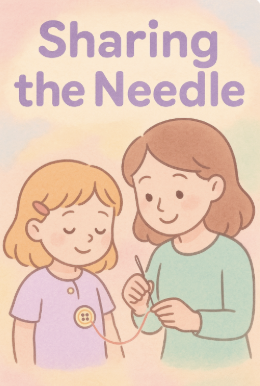

ChatGPTが書いた昔話なので、とてもミステリアスです。

最高ですね。

読んでもらってわかる通り、とても平易な英語で書かれています。

学習データセットとしては極めて学習しやすいグループに属します。


なお、<|endoftext|>が文章の最後に来ていますが、本来は文章の最初にある方が好ましいです。

理由としては、例えば別のファイルのテキストデータが前に来てしまうことがあるからです。

<|endoftext|> が冒頭にある場合

ファイル1のテキスト <|endoftext|>  ファイル2のテキスト

ただし今回は特に他のファイルもないので、このまま<|endoftext|>が文章の最後にある状態で進めていきます。

億単位の文字がある`/content/TinyStories-train.txt`を、1,000万文字のチャンクでencodeしていきます。

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`tiktoken`　`openai`　`get_encoding`　`"gpt2"`　`encoder`　`decoder`　`encode`　`decode`,　`output_bin_path`　`input_text_path`　`"w"`　`"r"`　`"ab"`　`"wb"`　`"utf-8"`　`chunk_size`　`chunk`　`np.array`　`tokens`　`np.int32`　`np.int8`　`tofile`　`arr`　`flush()`　`finish()`　`total_tokens`

In [ ]:
"""
import numpy as np
import tiktoken
import os

input_text_path = "/content/TinyStories-train.txt"
output_bin_path = "/content/TinyStories-train.bin"
chunk_size = 10_000_000
encoder = ________.___________(____) # TODO: FILL
# 出力バイナリファイルを空にしておく（既存データ削除）
with open(file=______________, mode=__) as f: # TODO: FILL
    pass
# 全トークン数をカウントする変数
total_tokens = 0
# テキストファイルを開き、トークン化 → バイナリ保存
with open(file=___________, mode=__, encoding=_____) as text_file:  # TODO: FILL
    with open(file=____________, mode=___) as bin_file: # TODO: FILL
        while True:
            # 一定サイズずつテキストを読み込む
            chunk = text_file.read(________) # TODO: FILL

            # 読み込みが終わったらループを抜ける
            if not chunk:
                break

            # テキストをトークンに変換
            tokens = ________._______(_____, allowed_special="all") # TODO: FILL

            # NumPy配列に変換（型をint32に）
            arr = ________(_____, dtype=______) # TODO: FILL

            # バイナリファイルに書き込む
            ___._____(bin_file) # TODO: FILL

            # ファイルへの書き込みを確実に反映
            bin_file.______ # TODO: FILL

            # 処理済みトークン数を更新
            ___________ += len(arr) # TODO: FILL

            # 進行状況を表示
            print(f"✅ {total_tokens:,} tokens processed...")

# 最終結果を表示
print(f"\n🎉 完了！ 合計 {total_tokens:,} トークンを保存しました。")
"""

In [ ]:
import numpy as np
import tiktoken
import os

input_text_path = "/content/TinyStories-train.txt"
output_bin_path = "/content/TinyStories-train.bin"
chunk_size = 10_000_000
encoder = tiktoken.get_encoding("gpt2")

# 全トークン数をカウントする変数
total_tokens = 0

# テキストファイルを開き、トークン化 → バイナリ保存
with open(input_text_path, "r", encoding="utf-8") as f:
    with open(output_bin_path, "ab") as out:
        while True:
            # 一定サイズずつテキストを読み込む
            chunk = f.read(chunk_size)

            # 読み込みが終わったらループを抜ける
            if not chunk:
                break

            # テキストをトークンに変換
            tokens = encoder.encode(chunk, allowed_special="all")

            # NumPy配列に変換（型をint32に）
            arr = np.array(tokens, dtype=np.int32)

            # バイナリファイルに書き込む
            arr.tofile(out)

            # ファイルへの書き込みを確実に反映
            out.flush()

            # 処理済みトークン数を更新
            total_tokens += len(arr)

            # 進行状況を表示
            print(f"✅ {total_tokens:,} tokens processed...")

# 最終結果を表示
print(f"\n🎉 完了！ 合計 {total_tokens:,} トークンを保存しました。")

<details>
<summary>クリックして答えを表示/非表示</summary>

```python
import numpy as np
import tiktoken
import os

input_text_path = "/content/TinyStories-train.txt"
output_bin_path = "/content/TinyStories-train.bin"
chunk_size = 10_000_000
encoder = tiktoken.get_encoding("gpt2")

# 全トークン数をカウントする変数
total_tokens = 0

# テキストファイルを開き、トークン化 → バイナリ保存
with open(input_text_path, "r", encoding="utf-8") as f:
    with open(output_bin_path, "ab") as out:
        while True:
            # 一定サイズずつテキストを読み込む
            chunk = f.read(chunk_size)

            # 読み込みが終わったらループを抜ける
            if not chunk:
                break

            # テキストをトークンに変換
            tokens = encoder.encode(chunk, allowed_special="all")

            # NumPy配列に変換（型をint32に）
            arr = np.array(tokens, dtype=np.int32)

            # バイナリファイルに書き込む
            arr.tofile(out)

            # ファイルへの書き込みを確実に反映
            out.flush()

            # 処理済みトークン数を更新
            total_tokens += len(arr)

            # 進行状況を表示
            print(f"✅ {total_tokens:,} tokens processed...")

# 最終結果を表示
print(f"\n🎉 完了！ 合計 {total_tokens:,} トークンを保存しました。")
```

3. `.bin` を NumPy形式（.npy） に変換  

バイナリファイルのままでもインデックスアクセスはできますが、numpyファイルの方が一般的なので、numpyファイルに変更します。

優位点：numpyファイルは`int32`のような型情報をファイル内部に含むため、他人が受け取った時にわかりやすい。

バイナリファイルでは、これは`int32`だという情報がファイル内に含まれないので、READMEまたはファイル名に記載するなどの方法が取られます。

```python
関数: np.fromfile
引数: file=バイナリファイルのパス, dtype=データ型（ここではnp.int32）
```

* `np.fromfile()` は、バイナリファイルから直接 NumPy 配列を生成する関数です。
* `dtype=np.int32`：バイナリデータを `int32`（4バイト整数）として読み取ります。
* 数値の生データ（例：トークンIDなど）を高速に読み込む用途で使われます。

In [ ]:
# 1️⃣ 生バイナリを int32 として読み込む。
# テキストデータではなく数値データなので、全てを読み込んでもシステムRAMへの負担は大きくない。
data = np.fromfile(file=output_bin_path, dtype=np.int32) # TODO: np.fromfile(file=ファイルパス, dtype=データ型) を適用
print("読み込んだトークン数:", len(data))

```python
関数: np.save
引数: file=保存先のパス, arr=保存するNumPy配列
```

* `np.save()` は、NumPy配列を `.npy` 形式で保存する関数です。
* `.npy` 形式は、NumPy配列を効率的に格納・読み出しできる公式フォーマットです。
* `file=npy_path`: 保存先ファイルのパス。

In [ ]:
# 2️⃣ 正しい .npy フォーマットで保存
npy_path = "/content/TinyStories-train.npy"
np.save(file=npy_path, arr=data) # TODO: 関数(引数)

4. `np.load(..., mmap_mode="r")` で メモリマップ読み込み

```python
関数: np.load
引数: file=読み込む .npy ファイルのパス, mmap_mode="r"
```

* `np.load()` は `.npy` 形式で保存された NumPy 配列を読み込む関数です。
* `mmap_mode="r"` を指定することで、**メモリマップ**（memory-mapping）が有効になります。

  * これにより、ファイル全体を一度に読み込まず、必要な部分だけを読み込むことができ、RAMの節約になります。
* `tokens = np.load(...)` により、`.npy` ファイルからトークン列（配列）を効率的に読み出します。

In [ ]:
tokens = np.load(file=npy_path, mmap_mode="r") # TODO: np.load(file=ファイルパス, mmap_mode="r") を適用
sample_tokens = tokens[100:200]
print(sample_tokens)

**Section 1: npyファイルの作成** <label><input type="checkbox"> Mark as Done</label>

### **Section 2: HuggingFaceへの保存**

今後もこの`TinyStories-train.npy`ファイルは使うので、HuggingFaceに保存します。

しかしHuggingFaceの仕様は非常に頻繁に変わるので、これが作成された2025年11月以降はうまくいかないかもしれません。

うまくいかなかった場合は仕様変更の問題なので、諦めてください。

認証まわりが関わる部分をデバッグするのはあまり初心者フレンドリーではありません。

npyファイルは以下のリポジトリなどで提供しているので、今回できなくても問題はありません。

https://huggingface.co/datasets/HayatoHongoEveryonesAI/TinyStories-test/tree/main



#### 方法1: HF APIを用いる

HuggingFaceアカウントの作成

⚠️ 44:16 ~ 47: 05 の部分だけ見てください！

[Watch the video!](https://youtu.be/qkS_Zc6uvbo)
- 3 minutes, no-sound
- Video ID: qkS_Zc6uvbo

---

次に、Datasetのリポジトリを作成します。

[Watch the video!](https://youtu.be/XiwL9uH7cbk)
- 50 seconds, no-sound
- Video ID: XiwL9uH7cbk

---

最後に、アクセストークンを発行します。

以下のサイトにアクセスしてください。

https://huggingface.co/settings/tokens

[Watch the video!](https://youtu.be/LuqQUi7Y47I)
- 45 seconds, no-sound
- Video ID: LuqQUi7Y47I


In [ ]:
# HF_TOKENは https://huggingface.co/settings/tokens に自分のHFアカウントでログインして入手する。

from huggingface_hub import login
login()

```python
クラス: HfApi
引数：なし
```

* `HfApi` は、Hugging Face Hub 上のモデルやデータセット、スペース、ユーザー情報などを操作するためのクラスです。
* `HfApi()` によって、このAPIクライアントのインスタンスを作成します。
* 作成した `api` を通して、リポジトリの作成や削除、アップロードなどの操作が可能になります。



In [ ]:
# 事前にデータセットのレポジトリを作成してください。

from huggingface_hub import HfApi

# Hugging Face Hubと対話するためのAPIインスタンスの作成
api = HfApi()  # TODO:  HfApiクラスのインスタンスを作成

In [ ]:
api.upload_file(
    path_or_fileobj="/content/TinyStories-train.npy",
    repo_id="HayatoHongoEveryonesAI/TinyStories-test",  # TODO: "YOUR_USERNAME/YOUR_REPO_NAME" で指定する。最後に ","を忘れないこと。
    repo_type="dataset", # データセットリポジトリかモデルリポジトリか
    path_in_repo="TinyStories-train.npy"   # リポジトリ上に保存するためのファイル名
)

#### **方法2: ローカルを使う（方法1がうまくいかなかった方向け）**

HuggingFaceの仕様は頻繁に変わるので、うまくいかなかった方向けに別の方法を紹介します。

まず、ファイルをローカルのパソコンにダウンロードします。

ローカルのパソコンからHuggingFaceにアップロードしましょう。

通信が重たいので、Wifi環境でお願いします。

（方法1がうまくいかず、wifiがない方は次のセクションへ進んでください。）

ディスクサイズの1.8GBのファイルですが、ダウンロードには非常に時間がかかります。

10分ほど待ってください。

In [ ]:
from google.colab import files
files.download('/content/TinyStories-train.npy')

次に、ダウンロードしたファイルをアップロードします。

[Watch the video!](https://youtu.be/IP9Mcq9hWx4)
- 4 minutes, no-sound
- Video ID: IP9Mcq9hWx4

**Section 2: HuggingFaceへの保存** <label><input type="checkbox"> Mark as Done</label>

### **Section 3:TinyStoriesデータセットでの学習**

DataLoaderに変更はありません。

In [ ]:
import torch
import numpy as np

class DataLoader:
    def __init__(self, npy_path, config):
        # 大きなトークン化済みファイル（.npy）をメモリマップで開き、
        # 必要な部分だけをランダムに読み出すデータローダー。
        self.config = config  # モデル設定（batch_size, seq_lenなど）

        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab

        # 巨大なトークン化済み .npy ファイルをメモリマップで開く
        self.data = np.load(npy_path, mmap_mode="r")

        # 訓練・検証用データの範囲を決める（実データは共有）
        self.train_data, self.val_data = self.split_data()

    def split_data(self):
        # データを 90%:10% に分割し、インデックス範囲で保持
        split_index = int(0.9 * len(self.data))
        return (0, split_index), (split_index, len(self.data))

    def get_batch(self, split):

        # 指定された split ('train' or 'val') からランダムにバッチを作る。
        # メモリに乗らない巨大ファイルから、必要部分だけをスライスして読み込む。

        # splitに応じたデータ範囲を取得
        range_start, range_end = (
            self.train_data if split == 'train' else self.val_data
        )

        # ランダムに開始位置を選ぶ
        start_indices = np.random.randint(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # 各開始位置から連続したトークン列を取り出してバッチ化
        # Pytorchの`nn.Embedding`は torch.int64 しか受け付けない。
        # np.int64に変換した状態で torch.from_numpy を適用すると、torch.int64 に変換される。
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(np.int64)
            )
            for start in start_indices
        ])

        # 1トークン先をターゲットにする
        # Pytorchの`nn.Embedding`はtorch.int64しか受け付けないため、np.int64に変換する必要がある。
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(np.int64)
            )
            for start in start_indices
        ])

        # GPUなどのデバイスに転送
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )

モデルクラスにも変更はありません。

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

class PositionEmbedding(nn.Module):
    def __init__(self, input_sequence_length = 8, embedding_dim = 8):
        super().__init__()
        # 位置埋め込み層
        self.position_embedding_layer = nn.Embedding(input_sequence_length, embedding_dim)

    def forward(self, input_indices):
        # 入力テンソル input_indices の形状：[バッチサイズ、シーケンス長]。
        sequence_length = input_indices.shape[1]

        # シーケンス長に応じた位置インデックスを作成する（例：[0, 1, 2, ..., sequence_length-1]）
        position_indices = torch.arange(sequence_length, device=input_indices.device)

        # 位置インデックスの埋め込みベクトルを取得する
        position_embeddings = self.position_embedding_layer.forward(position_indices)

        return position_embeddings

class EmbeddingModule(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # 各トークンの埋め込み層
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)  # 単語埋め込み層
        self.position_embedding_layer = PositionEmbedding(input_sequence_length = config.input_sequence_length, embedding_dim = config.embedding_dim)  # 位置情報を埋め込む

    def forward(self, input_indices):
        # トークン埋め込みを取得
        token_embeddings = self.token_embedding_layer.embed(input_indices)

        # 位置埋め込みを取得する
        position_embeddings = self.position_embedding_layer.forward(input_indices)

        # トークン埋め込みと位置埋め込みを追加する
        embeddings = position_embeddings + token_embeddings
        return embeddings


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # ドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)
        self.head_size = head_size

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        # 出力のドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        # 最終出力にドロップアウトを適用する
        output = self.dropout.forward(projected)

        return output

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            nn.Dropout(config.dropout_rate),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits

class nanoGPT(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.embedding = EmbeddingModule(vocab_size, config=config)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # テキストを生成する
    def generate(self, input_indices, max_new_tokens):
        # 指定したトークン数max_new_tokensのみ生成する
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # 入力を切り取る

            # 順伝播は `(likelihood, loss)` を返す—`likelihood` のみを `logits` として保持する。
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
            probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

            # 次のトークンをサンプリングする
            next_token = torch.multinomial(probs, num_samples=1)

            # 新しいトークンを統合し、input_indicesを更新する。
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # 最終的な`input_indices`を返す。長さは元の`input_indices`＋`max_new_tokens`
        return input_indices

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        embeddings = self.embedding(input_indices)
        blocks_output = self.blocks(embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

今後から`tokens_per_second`を記録することがこれから重要になってきます。

`Trainer`クラスについては、`tokens_per_second`を記録するリストを追加します。

In [ ]:
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        ########## NEW ##########
        self.tokens_per_second_list = []
        ########## NEW ##########
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # (configで指定された回数+1)だけtrain_stepを実行する。
        for step in range(self.config.total_training_steps+1):
            # 100回ごとに評価する。
            if step % self.config.evaluation_frequency == 0:
                if step == 0:
                  tokens_per_second = None
                  total_train_time = 0
                else:
                  current_eval_start_time = time.time()
                  evaluation_interval = current_eval_start_time - last_eval_end_time
                  total_train_time += evaluation_interval
                  tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
                  tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

                eval_loss = self.evaluate()
                total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

                print(
                    f"step {step:05d} | "
                    f"train loss {eval_loss['train']:.4f} | "
                    f"val loss {eval_loss['val']:.4f} | "
                    f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                    f"tokens {total_seen_tokens:,} | "
                    f"time {total_train_time:.2f}s"
                )

                self.steps.append(step)
                self.train_losses.append(eval_loss['train'])
                self.val_losses.append(eval_loss['val'])
                ########## NEW ##########
                self.tokens_per_second_list.append(tokens_per_second)
                ########## NEW ##########
                self.total_seen_tokens_list.append(total_seen_tokens)
                self.total_train_time_list.append(total_train_time)

                # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
                last_eval_end_time = time.time()

            # 1回の学習ステップ（毎回行う主な処理）
            train_loss = self.train_step()

今回は1時間だけ学習させるので、次元数は512ではなく256とします。

計算予算に合わせたモデルサイズを設定するのが重要です。

In [ ]:
# モデル設定を保存する設定クラス
class ModelConfig:
    batch_size = 16
    input_sequence_length = 512  # データロードにかかる時間の割合を下げるため、長めのシークエンスを一度に取り出す。
    ########## NEW ##########
    total_training_steps = 10_000  # おおよそ1時間くらいかかる
    ########## NEW ##########
    device_type = 'cuda'  # 使用デバイスはGPUに固定する
    evaluation_frequency = 100  # モデル性能評価の頻度
    ########## NEW ##########
    learning_rate = 2e-3  # 学習率
    ########## NEW ##########
    evaluation_loops = 10  # 評価中の繰り返し回数
    ########## NEW ##########
    embedding_dim = 256  # 埋め込み次元数
    hidden_dim = 1024
    num_attention_heads = 4  # アテンションヘッドの数
    ########## NEW ##########
    layer_count = 4  # モデルの層数
    dropout_rate = 0.1  # ドロップアウト確率
    random_seed_value = 1337  # 再現性のための乱数シード

In [ ]:
# 設定を読み込みシードを設定する
config = ModelConfig()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

Dataloaderインスタンスを作成してください。


In [ ]:
data_loader = DataLoader(npy_path = "/content/TinyStories-train.npy", config = config) # TODO: クラス(インスタンス)

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
# モデルのパラメータ数を表示する
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import time
import threading

def keep_alive():
    while True:
        print("Keeping session alive...")
        time.sleep(600)  # 10分間隔で出力

# keep_alive関数を実行するためのバックグラウンドスレッドのインスタンスを作成
thread = threading.Thread(target=keep_alive, daemon=True)
thread.start()
print("バックグラウンドでセッションを維持中...")

### 🚀 学習スタート！

今回は **15 GB RAM の T4 GPU** を使用し、
`batch size = 16`、`total steps = 10,000` の設定で進めます。

学習完了までにおよそ1時間かかります。

loss はあっとういまに下がっていきます。

finewebでは検証誤差を4.0を下回ることはできませんでしたが、

今回のTinyStoriesならばあっという間に4.0を下回ります。

⚠️: TODO問題がまだ残っている関係で、自動実行にできないので、1時間で帰ってきてください！

2時間以上経過するとセッションが自動で切断されます！

In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

横軸を`Step`、縦軸を`Loss`として`matplotlib`を使って描画しましょう。

In [ ]:
# グラフ描画。
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.train_losses, label='Train Loss')
plt.plot(trainer.steps, trainer.val_losses, label='Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 推論もやってみる
# 評価モードに切り替え。ドロップアウトを無効化する。
model.eval()
print("Model set to eval mode")

昔話を生成しましょう。promptを入力してください。

```plain
One day, there was a little girl named Lilly.
```

In [ ]:
prompt = "One day, there was a little girl named Lilly." # TODO: Typing
print(f"\n入力プロンプト: {prompt}")

encoder = tiktoken.get_encoding("gpt2")

# トークナイズしてテンソル化
encoded = encoder.encode(prompt, allowed_special="all") # テキストをIDにエンコード
print("encoded", encoded)
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
print(encoded_tensor)
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
print(encoded_tensor)
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
print(encoded_tensor)

In [ ]:
# テキスト生成
generated_text = model.generate(encoded_tensor, max_new_tokens=256)

生成されたテキストを確認してみましょう。

T4 GPU でのたった1時間の学習ですが、比較的スムーズな文章が生成されています。

In [ ]:
decoded_text = encoder.decode(generated_text[0].tolist())
print(decoded_text)

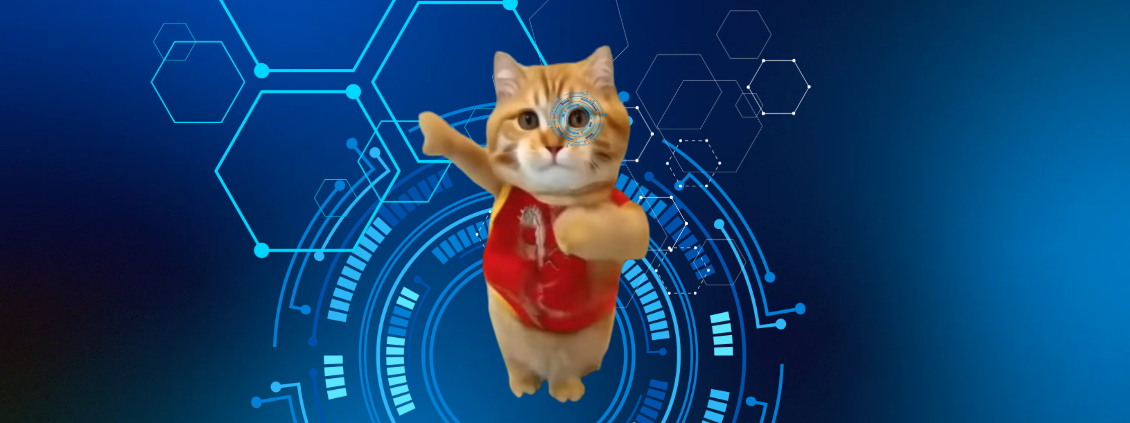

今回もT4 GPUをたっぷり使って学習してるので、学習ログはきちんと保管しましょう。

In [ ]:
# 学習済み trainer からログをまとめる
results = {
    "step": trainer.steps,
    "train_loss": trainer.train_losses,
    "val_loss": trainer.val_losses,
    "tokens_per_second": trainer.tokens_per_second_list,
    "total_seen_tokens": trainer.total_seen_tokens_list,
    "total_train_time": trainer.total_train_time_list,
}

print(results)

In [ ]:
import pandas as pd
# pandas の DataFrame に変換
df = pd.DataFrame(results)

In [ ]:
df

In [ ]:
# 保存先のフォルダを作成する
import os
dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter22"
os.makedirs(dir_path, exist_ok=True)

In [ ]:
# csvファイルとして保存する先のパスを指定する。
save_path = os.path.join(dir_path, "training_logs.csv")

In [ ]:
# CSVとして保存
df.to_csv(save_path, index=False)
print(f"✅ CSV saved to: {save_path}")

In [ ]:
# クラス属性を辞書化
config_class_dict = vars(config.__class__)
print(config_class_dict)

In [ ]:
# 辞書の (key, value) ペアを取得
config_dict_items = config_class_dict.items()
print(config_dict_items)

In [ ]:
config_dict = {
    key: value
    for key, value in config_dict_items
    if not key.startswith("__")
}

print(config_dict)

In [ ]:
# 保存先のファイルパスを作成する。
config_path = os.path.join(dir_path, "model_config.json")
print(config_path)

In [ ]:
import json
# ファイルを「書き込みモード(w)」で開き、変数`f`で操作できるようにする
with open(config_path, "w") as f:
    json.dump(config_dict, f)

print(f"✅ Config saved to: {config_path}")

In [ ]:
model_path = os.path.join(dir_path, "model.pt")
print(model_path)

In [ ]:
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved to: {model_path}")

**Section 3: 長時間の学習** <label><input type="checkbox"> Mark as Done</label>

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 22: TinyStories** <label><input type="checkbox"> Mark as Done</label>